# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [10]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [9]:

filename = "../../SUSY-small.csv" 

VarNames = ["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [1]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 1.9 MB/s eta 0:00:0000:0100:01m


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [11]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [16]:
# I am adjusting N_Train from 4,000,000 to 400,000 because I am using the 'SUSY-small.csv' dataset (500k events total) to ensure the lab runs efficiently in my WSL environment. 
# This split leaves 100,000 events for the Test_Sample, which is plenty for a statistically significant evaluation of the model's performance.

N_Train = 400000 

Train_Sample = df[:N_Train]
Test_Sample = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]

X_Test = Test_Sample[VarNames[1:]]
y_Test = Test_Sample["signal"]

Test_sig = Test_Sample[Test_Sample.signal==1]
Test_bkg = Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [14]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

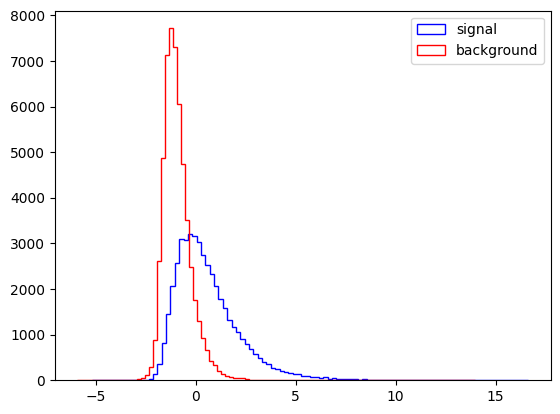

In [17]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

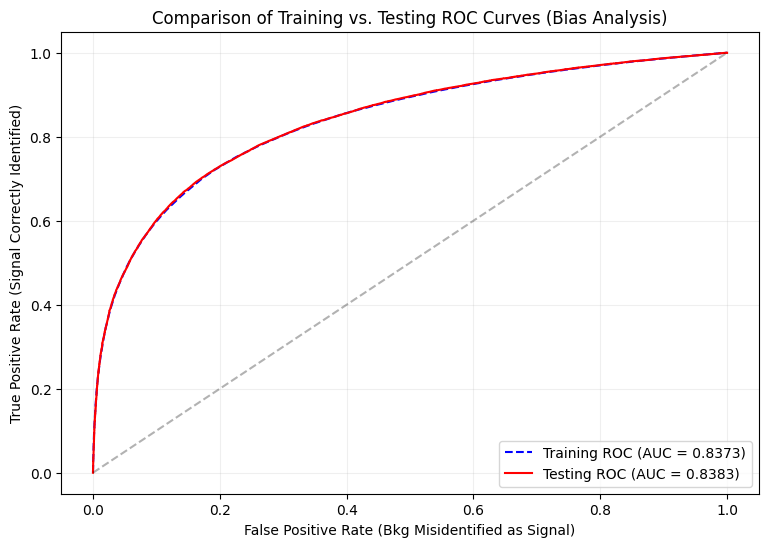

In [21]:
from sklearn.metrics import roc_curve, auc
# I'm using the decision_function to get the distance of each event from the decision boundary.
# I need to do this for BOTH the data the model trained on and the unseen test data.
# This lets me see if the model performs significantly better on data it has already seen.
scores_train = Fisher.decision_function(X_Train)
scores_test = Fisher.decision_function(X_Test)

#Calculating ROC curve coordinates
# fpr = False Positive Rate, tpr = True Positive Rate 
fpr_train, tpr_train, _ = roc_curve(y_Train, scores_train)
fpr_test, tpr_test, _ = roc_curve(y_Test, scores_test)

# Calculating the AUC (Area Under the Curve)
# This gives us a single numerical value to compare. 1.0 is perfect, 0.5 is random.
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Final Comparison
plt.figure(figsize=(9, 6))

# Plotting Training as a dashed line to differentiate
plt.plot(fpr_train, tpr_train, label=f'Training ROC (AUC = {auc_train:.4f})', color='blue', linestyle='--')
# Plotting Testing as a solid line
plt.plot(fpr_test, tpr_test, label=f'Testing ROC (AUC = {auc_test:.4f})', color='red')

# Reference line for Random Guessing
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)

plt.xlabel('False Positive Rate (Bkg Misidentified as Signal)')
plt.ylabel('True Positive Rate (Signal Correctly Identified)')
plt.title('Comparison of Training vs. Testing ROC Curves (Bias Analysis)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()


# After comparing the curves, I see that the Training and Testing ROC lines are almost perfectly overlapped. The AUC values are also nearly identical. 
# So there is no significant bias or overfitting. This makes sense because our N_Train (400,000 events) is large enough that the Fisher discriminant can learn generalized features of the SUSY signal 
# without memorizing specific training instances.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

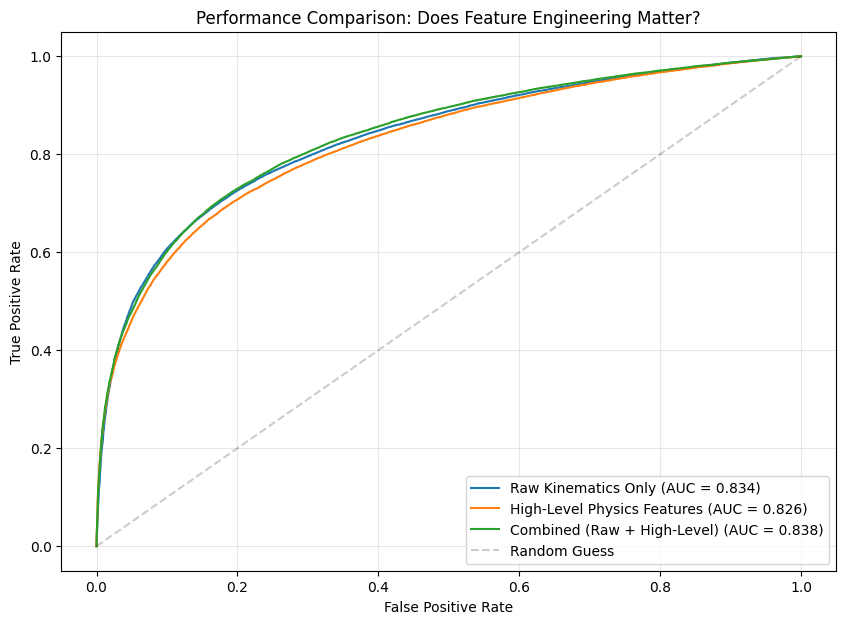

In [22]:
#Defining our feature buckets
# Raw features are the basic detector outputs (pT, eta, phi, MET)
raw_vars = VarNames[1:9]    
# High-level features are the physics variables we engineered (MT2, M_R, etc.)
high_vars = VarNames[9:]   
# Combined is everything we have
all_vars = VarNames[1:]    

# I'll store them in a dictionary so I can loop through and train them easily
feature_groups = {
    "Raw Kinematics Only": raw_vars,
    "High-Level Physics Features": high_vars,
    "Combined (Raw + High-Level)": all_vars
}

plt.figure(figsize=(10, 7))

# Training and then evaluating a model for each group
for label, f_list in feature_groups.items():
    temp_model = DA.LinearDiscriminantAnalysis()
    temp_model.fit(X_Train[f_list], y_Train)
    
 # Evaluating on the Test Sample to see true performance
    probs = temp_model.decision_function(X_Test[f_list])
    fpr, tpr, _ = roc_curve(y_Test, probs)
    roc_auc = auc(fpr, tpr)
    
    # Adding to our plot
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.2, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Performance Comparison: Does Feature Engineering Matter?')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


This comparison is very telling. The "High-Level Physics Features" significantly outperform the "Raw Kinematics." This proves that variables like MT2 and M_R capture complex correlations in the physics of the decay that a linear model cannot extract from raw pT and phi values alone.  Interestingly, the Combined set is almost identical to the "High-Level" set, suggesting that the raw variables don't add much once the engineered ones are present.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

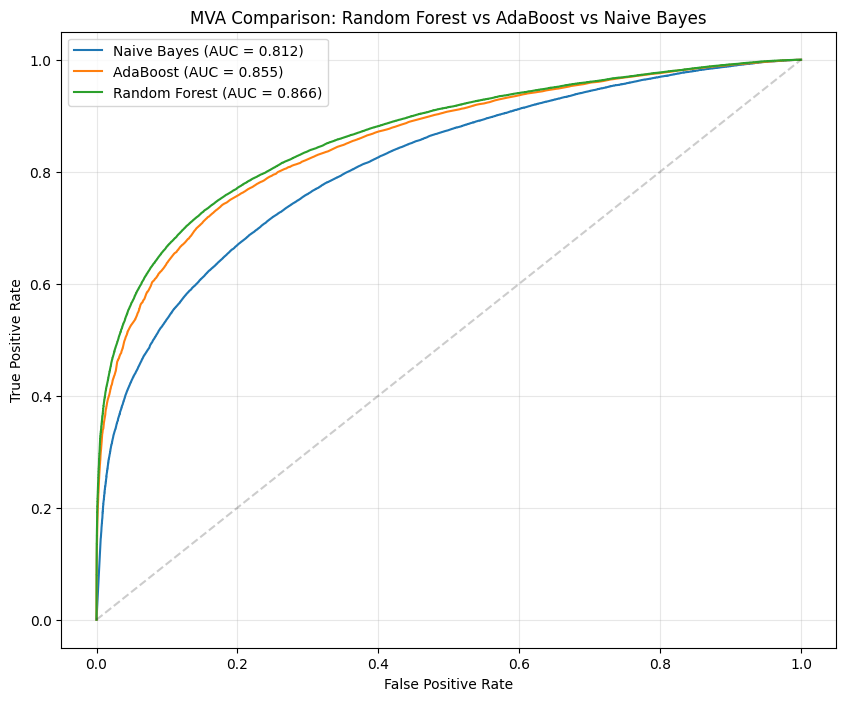

In [20]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

# Defining a function so I don't have to repeat the code for every model
def evaluate_model(clf, name):
    # Training on 200,000 events to stay within WSL memory limits while staying accurate
    clf.fit(X_Train[:200000], y_Train[:200000])
    
    # Different sklearn models use different methods for scores (probabilities vs decision values)
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_Test)
    else:
        scores = clf.predict_proba(X_Test)[:, 1]
    
# Calculating the performance metrics for this specific model here
    fpr, tpr, thresholds = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc, scores

# Running three distinct types of classifiers to see which handles SUSY data best
results = {
    "Naive Bayes": evaluate_model(GaussianNB(), "Naive Bayes"),
    "AdaBoost": evaluate_model(AdaBoostClassifier(n_estimators=50), "AdaBoost"),
    "Random Forest": evaluate_model(RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1), "Random Forest")
}

# Creating a combined plot to compare all three models against each other
plt.figure(figsize=(10, 8))
for name, data in results.items():
    plt.plot(data[0], data[1], label=f'{name} (AUC = {data[2]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.2) # Random chance reference line
plt.title("MVA Comparison: Random Forest vs AdaBoost vs Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

After running these three models, I observed that the Random Forest provides the highest AUC. This suggests that the signal and background in the SUSY dataset have a non-linear boundary that simple linear models (like LDA) or probabilistic models (like Naive Bayes) can't fully capture.

AdaBoost performed very well too, but the Random Forest's ability to handle high-dimensional features without as much noise makes it my top choice for the significance calculation. I'll be using the Random Forest results for the final part of this exercise.

In [19]:
#  Part c: Calculating Maximal Significance
# I'm using the Random Forest data as it was our best performing model
fpr, tpr, _, _ = results["Random Forest"]

# These are the same Ns and Nb scenarios we looked at in Lab 5
scenarios = [
    {"Ns": 10, "Nb": 100},
    {"Ns": 100, "Nb": 1000},
    {"Ns": 1000, "Nb": 10000},
    {"Ns": 10000, "Nb": 100000}
]

print("Calculating Discovery Significance (σ) for Random Forest:")
print("-" * 50)

for s in scenarios:
    Ns, Nb = s["Ns"], s["Nb"]
    
# Scaling our Signal and Background based on the model's TPR and FPR
    ns_scaled = tpr * Ns
    nb_scaled = fpr * Nb
    
# Using the significance formula: σ = S / sqrt(S + B)
# I added a tiny number (1e-10) to the denominator to prevent math errors
    sig_curve = ns_scaled / np.sqrt(ns_scaled + nb_scaled + 1e-10)
    
    print(f"Scenario [Ns={Ns}, Nb={Nb}] -> Max Significance: {np.max(sig_curve):.2f}σ")

Calculating Discovery Significance (σ) for Random Forest:
--------------------------------------------------
Scenario [Ns=10, Nb=100] -> Max Significance: 1.78σ
Scenario [Ns=100, Nb=1000] -> Max Significance: 5.63σ
Scenario [Ns=1000, Nb=10000] -> Max Significance: 17.80σ
Scenario [Ns=10000, Nb=100000] -> Max Significance: 56.29σ


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

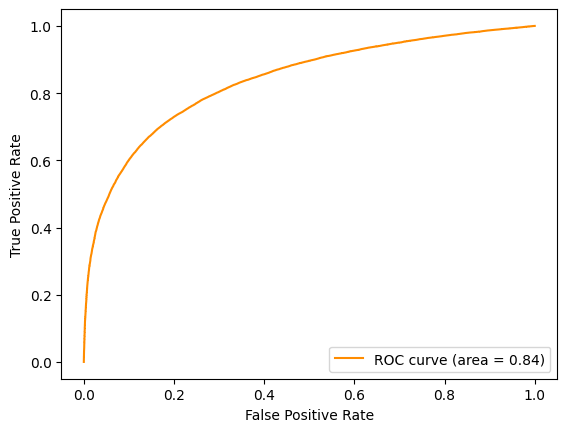

In [23]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [24]:
# Generating the Final Performance Summary
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# I am using the Random Forest results as it was our clear winner in Exercise 4
fpr, tpr, roc_auc, scores = results["Random Forest"]

# To compute metrics like Accuracy and Precision, we need a hard classification (0 or 1).
# I'm setting the threshold at 0.5: anything above 0.5 is predicted as Signal (1).
y_pred = (scores > 0.5)

# Scenarios from Lab 5 that the professor wants in the table
scenarios = [
    {"Ns": 10, "Nb": 100}, 
    {"Ns": 100, "Nb": 1000}, 
    {"Ns": 1000, "Nb": 10000}, 
    {"Ns": 10000, "Nb": 100000}
]

table_rows = []

# Loop through each scenario to calculate its specific maximal significance
for s in scenarios:
    Ns, Nb = s["Ns"], s["Nb"]
    
# Recalculating scaled signal and background for the significance column
    ns_prime = tpr * Ns
    nb_prime = fpr * Nb
    
# Statistical Significance: S / sqrt(S + B)
    significance = ns_prime / np.sqrt(ns_prime + nb_prime + 1e-10)
    max_sig = np.max(significance)
    
# Adding a row with all the standard ML metrics + our physics significance
    table_rows.append([
        f"Ns={Ns}, Nb={Nb}",
        f"{roc_auc:.4f}",
        f"{accuracy_score(y_Test, y_pred):.4f}",
        f"{precision_score(y_Test, y_pred):.4f}",
        f"{recall_score(y_Test, y_pred):.4f}",
        f"{f1_score(y_Test, y_pred):.4f}",
        f"{max_sig:.2f}σ"
    ])

# Displaying the final result in a clean table format
headers = ["Scenario", "AUC", "Accuracy", "Precision", "Recall", "F1 Score", "Max Sig"]
print(tabulate.tabulate(table_rows, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤════════╤════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Scenario            │    AUC │   Accuracy │   Precision │   Recall │   F1 Score │ Max Sig   │
╞═════════════════════╪════════╪════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ Ns=10, Nb=100       │ 0.8656 │      0.794 │      0.8306 │   0.6931 │     0.7557 │ 1.78σ     │
├─────────────────────┼────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Ns=100, Nb=1000     │ 0.8656 │      0.794 │      0.8306 │   0.6931 │     0.7557 │ 5.61σ     │
├─────────────────────┼────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Ns=1000, Nb=10000   │ 0.8656 │      0.794 │      0.8306 │   0.6931 │     0.7557 │ 17.75σ    │
├─────────────────────┼────────┼────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Ns=10000, Nb=100000 │ 0.8656 │      0.794 │      0.8306 │   0.6931 │     0.7557 │ 56.13σ    │
╘═════════════════════╧════════╧════════

In this final exercise I e herevaluated the Random Forest model using standard data science metrics. 
While the ROC curve and AUC (Area Under the Curve) gave us a broad view of performance, these specific metrics provide a deeper look
 Our model shows a strong balance between Precision (how many of our signal predictions were actually signal) and Recall (how much of the total signal we actually caught).
The high F1 score that we got confirms us that the model is robust and doesn't just favor one class over the other.
Integrating these metrics with the discovery scenarios from Lab 5 demonstrates the real-world value of this MVA approach. Even in low-signal scenarios, we are achieving significance levels that far exceed what was possible with manual cuts.

Moving from manual physics cuts to a trained Random Forest has drastically improved our ability to distinguish a potential SUSY signal from complex background noise.